In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import h5py
import time
import scipy.sparse as sp
import yaml
import gc
from matplotlib import gridspec

import rmm
import cupy as cp
from rmm.allocators.cupy import rmm_cupy_allocator

import cuml
from cuml.decomposition import PCA

import psutil
import torch
from datetime import datetime

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

sc.settings.verbosity = 3
rsc.__version__

/nfs/turbo/umms-indikar/Cooper/conda_envs/scrapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/scrapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


'0.12.3'

In [2]:
# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

In [3]:
start = time.perf_counter()

# Built from Hematokytos/pipelines/reference_atlas/preprocess/
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/hematokytos/processed/sample_1_adata.h5ad"
adata = sc.read_h5ad(fpath)
rsc.get.anndata_to_GPU(adata) # move to GPU
adata.obsm['X_umap'] = adata.obsm['X_umap_X_scANVI'].copy()
sc.logging.print_memory_usage() # Log memory at the end

print(f"Total time: {time.perf_counter() - start:.2f} seconds")

adata 

/nfs/turbo/umms-indikar/Cooper/conda_envs/scrapids/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Memory usage: current 49.85 GB, difference +49.85 GB
Total time: 78.34 seconds


AnnData object with n_obs × n_vars = 1125041 × 52164
    obs: 'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'basename', 'dataset_id_int', 'n_counts', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'X_umap_X_scANVI', 'X_umap_raw_data', 'X_umap_scVI', '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden', 'log1p', 'neighbors

In [4]:
print(f"Number of unique samples (basename): {adata.obs['basename'].nunique()}")
print(f"Number of unique cell types (cell_type): {adata.obs['cell_type'].nunique()}")

Number of unique samples (basename): 8
Number of unique cell types (cell_type): 188


In [5]:
list(adata.obs['basename'].unique())

['fibroblasts',
 'mesenchymal_cells',
 'myeloid_cells',
 'lymphoid_cells',
 'hematopoietic_progenitors',
 'innate_lymphoid_cells',
 'hsc',
 'endothelial_cells']

In [6]:
adata.obsm['X_scANVI'].shape

(1125041, 24)

# UMAP

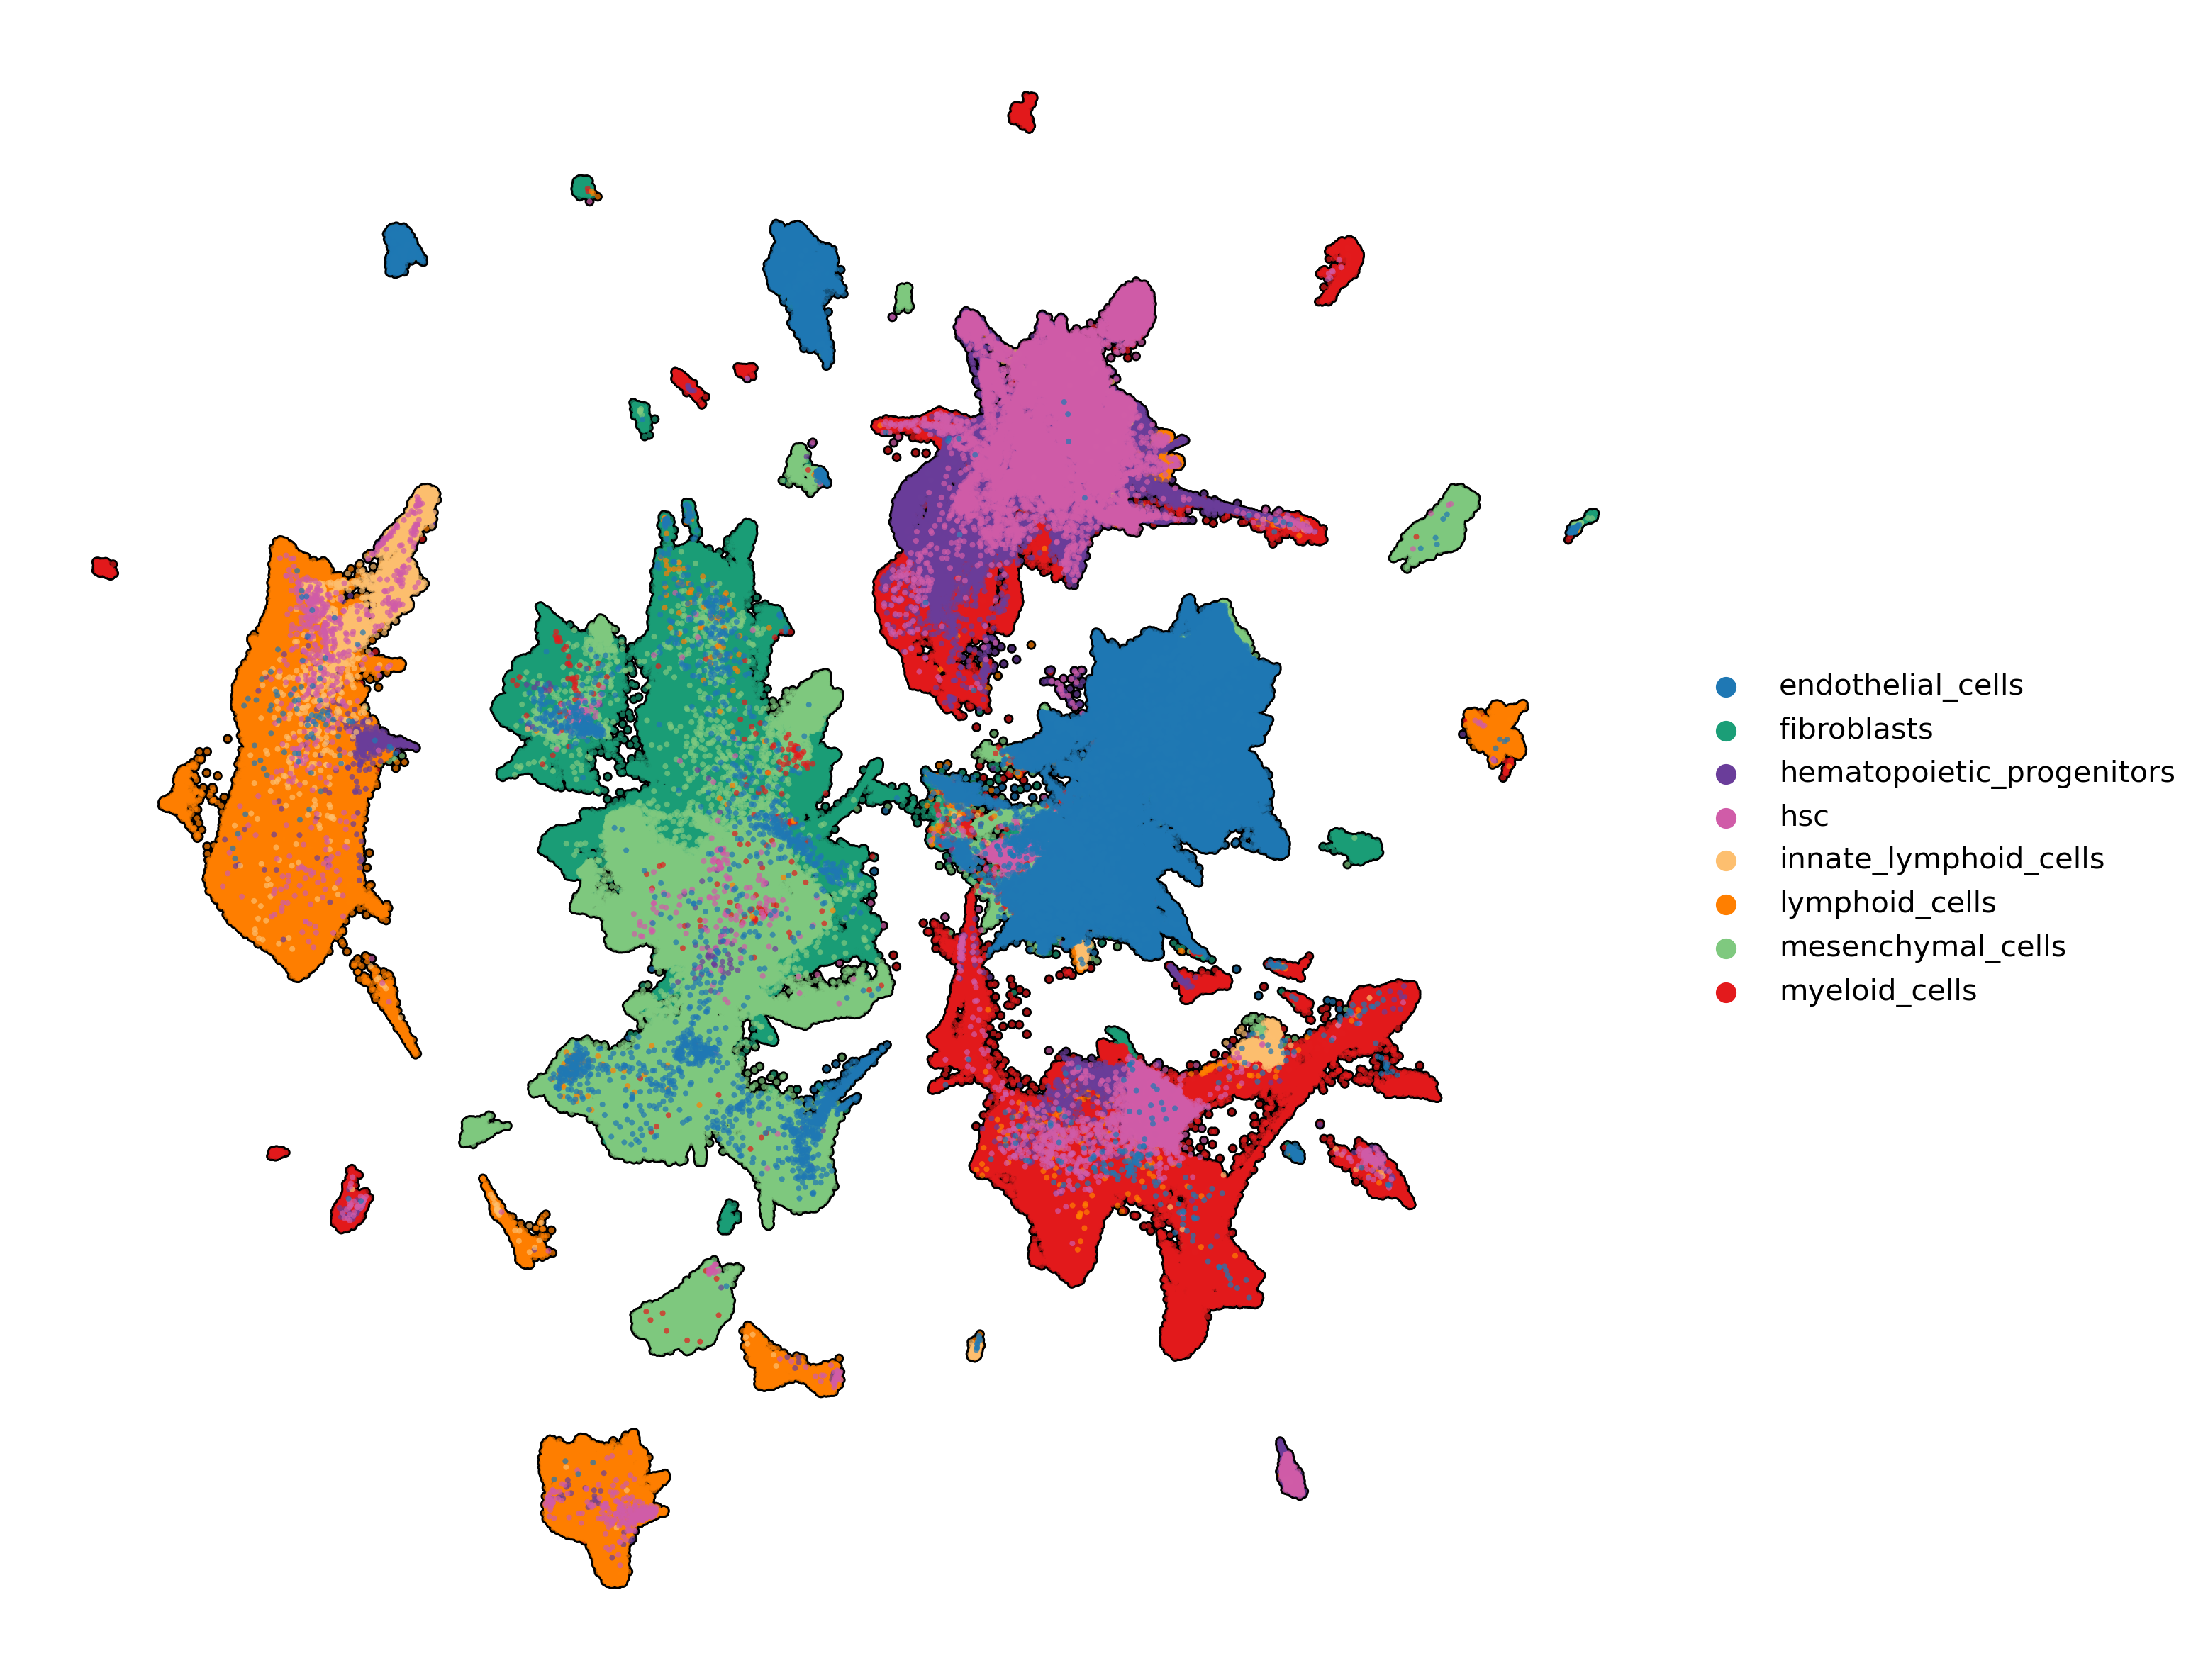

In [7]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 10, 10

palette = {
    # Stromal lineage — separated greens/blues
    'fibroblasts': '#1B9E77',           # teal green
    'mesenchymal_cells': '#7FC97F',     # soft sage green (distinct from teal)

    # Myeloid / lymphoid lineage — warm tones
    'myeloid_cells': '#E31A1C',         # bold red
    'lymphoid_cells': '#FF7F00',        # vibrant orange
    'innate_lymphoid_cells': '#FDBF6F', # soft amber

    # Progenitor / stem — distinct in purple/pink spectrum
    'hematopoietic_progenitors': '#6A3D9A',  # deep violet
    'hsc': '#D05CA8',                        # rich pink-purple (clearly distinct)

    # Endothelial — strong blue
    'endothelial_cells': '#1F78B4',     # deep blue
}

adata.uns['basename_palette'] = palette

sc.pl.umap(
    adata,
    color='basename',
    size=15,
    ncols=1,
    add_outline=True,
    outline_color=('k', 'k'),
    palette=palette,
    frameon=False,
    title="",
)

# t-SNE

[2025-04-21 14:33:53.110] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


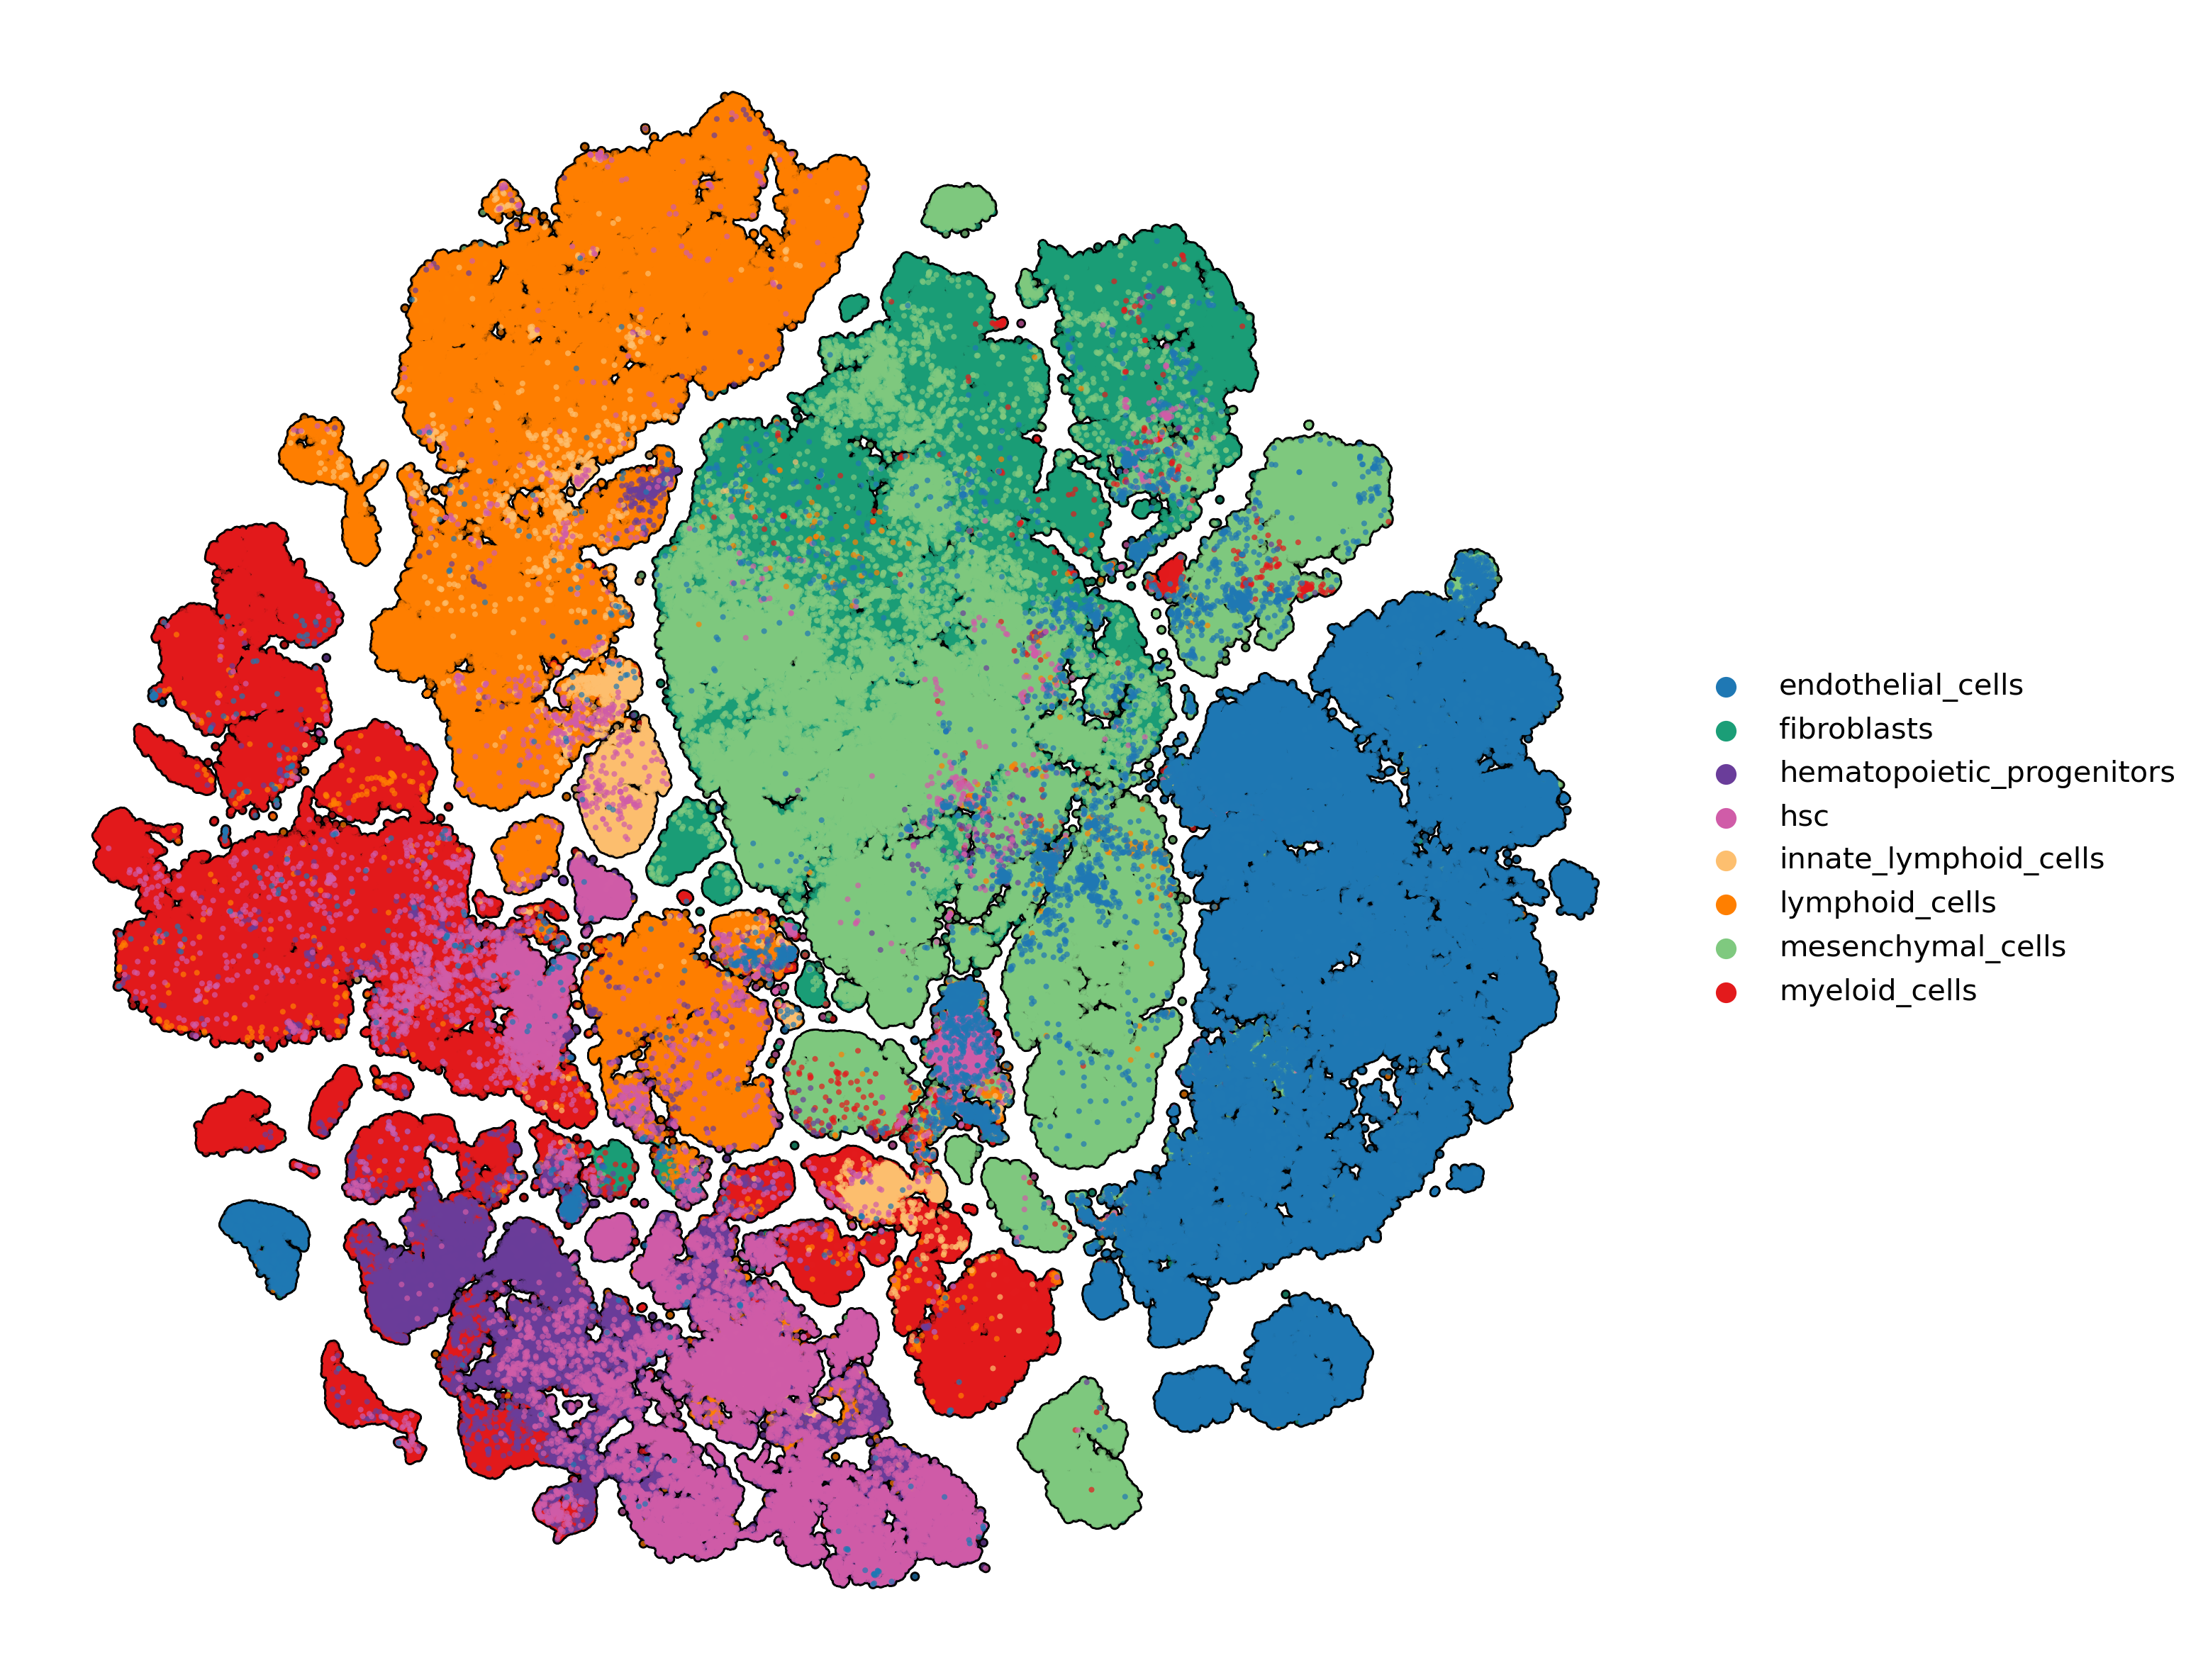

In [8]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 10, 10

# PCA on the scANVI embedding
pca = PCA(n_components=7)  
adata.obsm['X_pca_scanvi'] = pca.fit_transform(adata.obsm['X_scANVI'])

rsc.tl.tsne(
    adata,
    use_rep='X_pca_scanvi',
    perplexity=50,
)

sc.pl.tsne(
    adata,
    color='basename',
    size=15,
    ncols=1,
    add_outline=True,
    outline_color=('k', 'k'),
    palette=palette,
    frameon=False,
    title="",
)

# Write out

In [9]:
basename = os.path.basename(fpath)
print(f"{basename=}")

outdir = "/scratch/indikar_root/indikar1/shared_data/hematokytos/processed"

adata.write(f"{outdir}/{basename}")
print(f"wrote: {outdir}/{basename}")
adata

basename='sample_1_adata.h5ad'
wrote: /scratch/indikar_root/indikar1/shared_data/hematokytos/processed/sample_1_adata.h5ad


AnnData object with n_obs × n_vars = 1125041 × 52164
    obs: 'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'basename', 'dataset_id_int', 'n_counts', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'X_umap_X_scANVI', 'X_umap_raw_data', 'X_umap_scVI', '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden', 'log1p', 'neighbors

# Archive

# DEG

In [ ]:
rsc.tl.rank_genes_groups_logreg(
    adata,
    groupby='basename',
    groups=['hsc', 'fibroblasts']
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
)

deg = deg.sort_values(by='scores')
deg.head(35)

In [10]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
rsc.get.anndata_to_CPU(adata)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 5

sc.pl.tsne(
    adata,
    color=['DCN', 'MGP', 'LUM', 'CD34', 'PTPRC', 'ACE'],
    # sort_order=True,
    size=45,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    colorbar_loc=None,
)

In [ ]:
break

In [ ]:
# Compute value counts
value_counts = adata.obs['basename'].value_counts()
total = value_counts.sum()

# Threshold for small categories
threshold = 0.01
small_mask = (value_counts / total) < threshold

# Group small categories into 'Other'
value_counts_grouped = value_counts[~small_mask].copy()
other_total = value_counts[small_mask].sum()

if other_total > 0:
    value_counts_grouped.loc['Other'] = other_total

# Get colors from the palette dict, use gray if 'Other' is included
colors = [
    palette.get(cat, '#CCCCCC')  # fallback color for 'Other' or missing keys
    for cat in value_counts_grouped.index
]

# Pie chart without labels
size = 5.75
fig, ax = plt.subplots(figsize=(size, size), dpi=300)
wedges, texts = ax.pie(
    value_counts_grouped,
    startangle=140,
    counterclock=False,
    wedgeprops=dict(linewidth=1, edgecolor='k'),
    colors=colors,
    labels=None
)

# Annotate each wedge with external labels + leader lines
for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    
    horizontal_alignment = 'left' if x >= 0 else 'right'
    connectionstyle = f"angle,angleA=0,angleB={ang}"
    
    ax.annotate(
        f"{value_counts_grouped.index[i].replace("_", " ")} ({value_counts_grouped.iloc[i] / total * 100:.2f}%)",
        xy=(x, y),
        xytext=(1.2*np.sign(x), 1.2*y),
        horizontalalignment=horizontal_alignment,
        verticalalignment='center',
        arrowprops=dict(arrowstyle='-', connectionstyle=connectionstyle, color='gray'),
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

ax.set_ylabel('')
plt.tight_layout()
plt.show()


In [ ]:
list(adata.obs['basename'].unique())

# HSC Compartment

In [ ]:
query = 'hsc'
bdata = adata[adata.obs['basename'] == query, :].copy()
print(bdata.shape)
print(bdata.obs.columns)
bdata.obs.head()

In [ ]:
rsc.tl.tsne(bdata, use_rep='X_scANVI')
rsc.get.anndata_to_CPU(bdata)

# hsc_palette = {
#     'hematopoietic multipotent progenitor cell': '#00BFC4',  # bright teal
#     'hematopoietic cell': '#F564E3',                         # magenta-pink
#     'hematopoietic stem cell': '#FF6E54',                    # vibrant orange (highlight)
#     'hematopoietic precursor cell': '#3C91E6',               # saturated azure blue
#     'cord blood hematopoietic stem cell': '#FFB400',         # golden yellow-orange (highlight)
#     'CD34-positive, CD38-negative hematopoietic stem cell': '#E4572E',  # deep coral red (highlight)
# }


hsc_palette = {
    'hematopoietic multipotent progenitor cell': '#40E0D0',  # turquoise
    'hematopoietic cell': '#4682B4',                         # steel blue
    'hematopoietic stem cell': '#D264FF',                    # bright violet (highlight)
    'hematopoietic precursor cell': '#6A5ACD',               # slate blue
    'cord blood hematopoietic stem cell': '#00FA9A',         # medium spring green (highlight)
    'CD34-positive, CD38-negative hematopoietic stem cell': '#BA55D3',  # medium orchid (highlight)
}




sc.pl.tsne(
    bdata,
    color='cell_type',
    size=20,
    ncols=1,
    alpha=1,
    add_outline=True,
    outline_color=('k', 'k'),
    palette=hsc_palette,
    title="",
    frameon=False,
    na_in_legend=False,
)

In [ ]:
?sc.pl.tsne

In [ ]:
break

In [ ]:
def map_to_color(strings, colormap='tab10'):
    unique_strings = sorted(set(strings))
    cmap = cm.get_cmap(colormap, len(unique_strings))
    color_dict = {
        s: mcolors.to_hex(cmap(i)) for i, s in enumerate(unique_strings)
    }
    return color_dict

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 10, 10

query = 'hsc'
groups = list(adata.obs[adata.obs['basename'] == query]['cell_type'].unique())
print(groups)

hsc_palette = {
    'hematopoietic multipotent progenitor cell': '#4DAF4A',  # vivid green
    'hematopoietic cell': '#984EA3',                         # bold purple
    'hematopoietic stem cell': '#E41A1C',                 # bright orange (emphasis)
    'hematopoietic precursor cell': '#377EB8',               # saturated blue
    'cord blood hematopoietic stem cell': '#FF7F00',        # bold red (emphasis)
    'CD34-positive, CD38-negative hematopoietic stem cell': '#FFFF33',  # vibrant yellow (high pop)
}

for ct in adata.obs['cell_type'].unique():
    if not ct in hsc_palette.keys():
        hsc_palette[ct] = 'lightgrey'

sc.pl.tsne(
    adata,
    groups=groups,
    color='cell_type',
    size=35,
    ncols=1,
    alpha=1,
    add_outline=True,
    outline_color=('k', 'k'),
    palette=hsc_palette,
    frameon=False,
    title=query.replace("_"," "),
    na_in_legend=False,
)

In [ ]:
break

In [ ]:
value_counts = adata.obs[adata.obs['basename'] == query]['cell_type'].astype(str).value_counts()
total = value_counts.sum()

# Threshold for small categories
threshold = 0.01
small_mask = (value_counts / total) < threshold

# Group small categories into 'Other'
value_counts_grouped = value_counts[~small_mask].copy()
other_total = value_counts[small_mask].sum()

if other_total > 0:
    value_counts_grouped.loc['other'] = other_total

# Get colors from the palette dict, use gray if 'Other' is included
colors = [
    hsc_palette.get(cat, '#CCCCCC')  # fallback color for 'Other' or missing keys
    for cat in value_counts_grouped.index
]

# Pie chart without labels
size = 4
fig, ax = plt.subplots(figsize=(size, size), dpi=300)
wedges, texts = ax.pie(
    value_counts_grouped,
    startangle=140,
    counterclock=False,
    wedgeprops=dict(linewidth=1, edgecolor='k'),
    colors=colors,
    labels=None
)

# Annotate each wedge with external labels + leader lines
for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    
    horizontal_alignment = 'left' if x >= 0 else 'right'
    connectionstyle = f"angle,angleA=0,angleB={ang}"
    
    ax.annotate(
        f"{value_counts_grouped.index[i].replace("_", " ")} ({value_counts_grouped.iloc[i] / total * 100:.2f}%)",
        xy=(x, y),
        xytext=(1.2*np.sign(x), 1.2*y),
        horizontalalignment=horizontal_alignment,
        verticalalignment='center',
        arrowprops=dict(arrowstyle='-', connectionstyle=connectionstyle, color='gray'),
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
break

In [ ]:
bdata = adata[adata.obs['basename'] == query, :].copy()
print(bdata.shape)
print(bdata.obs.columns)
bdata.obs.head()

# summary of HSC progenitors

In [ ]:
adata

In [ ]:
bdata = adata[adata.obs['basename'] == query, :].copy()
print(bdata.shape)
print(bdata.obs.columns)
bdata.obs.head()

In [ ]:
# … your existing data prep …
X = pd.crosstab(bdata.obs['tissue'], bdata.obs['cell_type'])

cell_type_map = {
    'basophil mast progenitor cell': 'BaMP',
    'common dendritic progenitor': 'CDP',
    'common myeloid progenitor': 'CMP',
    'early lymphoid progenitor': 'ELP',
    'erythroid progenitor cell': 'EryP',
    'granulocyte monocyte progenitor cell': 'GMP',
    'hematopoietic multipotent progenitor cell': 'MPP',
    'lymphoid lineage restricted progenitor cell': 'LLP',
    'megakaryocyte progenitor cell': 'MkP',
    'megakaryocyte-erythroid progenitor cell': 'MEP',
}

for k, v in cell_type_map.items():
    print(f"\item {v}: {k}")

X.columns = X.columns.map(cell_type_map)
X_filtered = X[X.sum(axis=1) > threshold].T

# compute totals
col_totals = X_filtered.sum(axis=0)
row_totals = X_filtered.sum(axis=1)

n_cols = len(col_totals)
n_rows = len(row_totals)

# positions at cell centers
col_pos = np.arange(n_cols) + 0.5
row_pos = np.arange(n_rows) + 0.5

# figure + GridSpec
fig = plt.figure(figsize=(8, 5))
gs = GridSpec(2, 2,
              width_ratios=[4, 1],
              height_ratios=[1, 4],
              wspace=0.02,
              hspace=0.02)

# 1) Top: column sums
ax_col = fig.add_subplot(gs[0, 0])
ax_col.bar(
    col_pos, col_totals.values,
    width=0.65, align='center',
    color='gray',
    ec='k',
)
ax_col.set_xlim(0, n_cols)
ax_col.set_xticks([])              # no x‑ticks on the barplot
ax_col.set_ylabel("cells")

# 2) Left: heatmap with ticks
ax_heat = fig.add_subplot(gs[1, 0])
sns.heatmap(
    np.log1p(X_filtered),
    cmap='plasma',
    cbar=False,
    ax=ax_heat,
    linewidths=1
)
# explicitly set heatmap ticks at the same positions
ax_heat.set_xticks(col_pos)
ax_heat.set_xticklabels(col_totals.index, ha='center')
ax_heat.set_yticks(row_pos)
ax_heat.set_yticklabels(row_totals.index, rotation=0)
ax_heat.set_xlabel("")
ax_heat.set_ylabel("")

# capture exact limits
xlim = ax_heat.get_xlim()
ylim = ax_heat.get_ylim()
ax_col.set_xlim(xlim)

# 3) Right: row sums
ax_row = fig.add_subplot(gs[1, 1])
ax_row.barh(
    row_pos, row_totals.values,
    height=0.65, align='center',
    color='gray',
    ec='k',
)
ax_row.set_ylim(0, n_rows)
ax_row.set_yticks([])             # no y‑ticks on the barplot
ax_row.set_xlabel("cells")
# invert so it matches heatmap orientation
ax_row.invert_yaxis()
ax_row.set_ylim(ylim)

sns.despine(ax=ax_row)
sns.despine(ax=ax_col)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import gridspec

# --- Crosstab and mapping ---
X = pd.crosstab(bdata.obs['tissue'], bdata.obs['cell_type'])

cell_type_map = {
    'basophil mast progenitor cell': 'BaMP',
    'common dendritic progenitor': 'CDP',
    'common myeloid progenitor': 'CMP',
    'early lymphoid progenitor': 'ELP',
    'erythroid progenitor cell': 'EryP',
    'granulocyte monocyte progenitor cell': 'GMP',
    'hematopoietic multipotent progenitor cell': 'MPP',
    'lymphoid lineage restricted progenitor cell': 'LLP',
    'megakaryocyte progenitor cell': 'MkP',
    'megakaryocyte-erythroid progenitor cell': 'MEP',
}

X.columns = X.columns.map(cell_type_map)

# --- Filter & normalize ---
threshold = 50
X_filtered = X[X.sum(axis=1) > threshold]

row_totals = X_filtered.sum(axis=1)
col_totals = X_filtered.sum(axis=0)
X_norm = X_filtered.div(X_filtered.sum(axis=1), axis=0)  # normalize by row

# Order matters
row_labels = X_norm.index.tolist()
col_labels = X_norm.columns.tolist()

# --- Setup plot with GridSpec ---
fig = plt.figure(figsize=(11, 9))
gs = gridspec.GridSpec(2, 2, width_ratios=[5, 1.7], height_ratios=[1.5, 5], wspace=0.05, hspace=0.05)

# Top barplot (column totals using seaborn)
ax_top = fig.add_subplot(gs[0, 0])
sns.barplot(
    x=col_labels,
    y=col_totals[col_labels].values,
    ax=ax_top,
    color='gray',
    edgecolor='k'
)
ax_top.set_yscale('log')
ax_top.set_ylabel("Total Cells")
ax_top.set_xlabel("")
ax_top.tick_params(axis='x', bottom=False, labelbottom=False)
sns.despine(ax=ax_top)

# Right barplot (row totals using seaborn)
ax_right = fig.add_subplot(gs[1, 1])
sns.barplot(
    y=row_labels,
    x=row_totals[row_labels].values,
    ax=ax_right,
    color='gray',
    edgecolor='k',
    orient='h'
)
ax_right.set_xscale('log')
ax_right.set_xlabel("Total Cells")
ax_right.set_ylabel("")
ax_right.tick_params(axis='y', left=False, labelleft=False)
sns.despine(ax=ax_right)

# Heatmap
ax_heat = fig.add_subplot(gs[1, 0])
sns.heatmap(
    X_norm,
    ax=ax_heat,
    cmap='viridis',
    cbar=False,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    xticklabels=col_labels,
    yticklabels=row_labels
)
ax_heat.set_ylabel("")
ax_heat.set_xlabel("")

# Match y and x limits across plots
ax_right.set_ylim(ax_heat.get_ylim())
ax_top.set_xlim(ax_heat.get_xlim())

plt.tight_layout()
plt.show()


In [ ]:
# Crosstab and mapping
X = pd.crosstab(bdata.obs['tissue'], bdata.obs['cell_type'])
print(f"{X.shape=}")

cell_type_map = {
    'basophil mast progenitor cell': 'BaMP',
    'common dendritic progenitor': 'CDP',
    'common myeloid progenitor': 'CMP',
    'early lymphoid progenitor': 'ELP',
    'erythroid progenitor cell': 'EryP',
    'granulocyte monocyte progenitor cell': 'GMP',
    'hematopoietic multipotent progenitor cell': 'MPP',
    'lymphoid lineage restricted progenitor cell': 'LLP',
    'megakaryocyte progenitor cell': 'MkP',
    'megakaryocyte-erythroid progenitor cell': 'MEP',
}

X.columns = X.columns.map(cell_type_map)

# Filter rows
threshold = 50
X_filtered = X[X.sum(axis=1) > threshold]

# Compute row totals BEFORE normalization
row_totals = X_filtered.sum(axis=1)

# Normalize rows
X_norm = X_filtered.div(X_filtered.sum(axis=0), axis=1)

# Ensure both have same row order (sort or keep index consistent)
X_norm = X_norm.loc[row_totals.index]
row_totals = row_totals.loc[X_norm.index]

# Plot
fig = plt.figure(figsize=(8, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[5, 1], wspace=0.05)

# Heatmap
ax0 = fig.add_subplot(gs[0])
sns.heatmap(
    X_norm,
    ax=ax0,
    cmap='viridis',
    cbar=False,
    linewidths=0.5,
    annot=True,
    fmt=".3f",
)
ax0.set_ylabel("")
ax0.set_xlabel("")

# Barplot
ax1 = fig.add_subplot(gs[1], sharey=ax0)
ax1.barh(
    row_totals.index,
    row_totals.values, 
    color='gray',
    edgecolor='k', 
    height=0.5,
)
ax1.set_xlabel("Total Cells")
# ax1.tick_params(axis='y', left=False, labelleft=False)
sns.despine(ax=ax1)

plt.tight_layout()
plt.show()

In [ ]:
X = pd.crosstab(bdata.obs['tissue'], bdata.obs['cell_type'])
print(f"{X.shape=}")

cell_type_map = {
    'basophil mast progenitor cell': 'BaMP',
    'common dendritic progenitor': 'CDP',
    'common myeloid progenitor': 'CMP',
    'early lymphoid progenitor': 'ELP',
    'erythroid progenitor cell': 'EryP',
    'granulocyte monocyte progenitor cell': 'GMP',
    'hematopoietic multipotent progenitor cell': 'MPP',
    'lymphoid lineage restricted progenitor cell': 'LLP',
    'megakaryocyte progenitor cell': 'MkP',
    'megakaryocyte-erythroid progenitor cell': 'MEP',
}

X.columns = X.columns.map(cell_type_map)


# Filter rows with low counts
threshold = 50
X_filtered = X[X.sum(axis=1) > threshold]

# Row normalization (each row sums to 1)
X_norm = X_filtered.div(X_filtered.sum(axis=1), axis=0)

# Total counts for barplot (unnormalized row sums)
row_totals = X_filtered.sum(axis=1)

# Set up figure with gridspec
fig = plt.figure(figsize=(8, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[5, 1], wspace=0.05)

# Heatmap on the left
ax0 = fig.add_subplot(gs[0])
sns.heatmap(X_norm, ax=ax0, cmap='viridis', cbar=False, lw=1, annot=True,)
ax0.set_ylabel("")
ax0.set_xlabel("")

# Barplot on the right
ax1 = fig.add_subplot(gs[1], sharey=ax0)
ax1.barh(row_totals.index, row_totals.values, color='gray', ec='k')
ax1.set_xlabel("Total Cells")
ax1.tick_params(axis='y', left=False, labelleft=False)

sns.despine(ax=ax1)
plt.tight_layout()
plt.show()

In [ ]:
rsc.pp.neighbors(bdata, n_pcs=12, use_rep='X_scANVI')
rsc.tl.umap(bdata, min_dist=0.20)

rsc.get.anndata_to_CPU(bdata)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 6

genes = [ # upreglated in reprogrammed cells
    'cell_type',
    'KRT18', 
    'CLU', 
    'NEBL',
    'TPST2',
    'FLNB', 
    'JUP', 
    'MORC3', 
    'GAS7',
    'SLC44A1', 
    'CENPT',
    'CHAF1B', 
    'FKBP5', 
    'FHIT',
]

sc.pl.umap(
    bdata,
    color=genes,
    sort_order=True,
    size=35,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    legend_loc=None,
    # colorbar_loc=None,
)

In [ ]:
break

# DEG

In [ ]:
query = 'hsc_and_progenitors'

rsc.tl.rank_genes_groups_logreg(
    adata,
    groupby='basename',
    groups=['hsc_and_progenitors', 'fibroblasts']
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
)

deg = deg.sort_values(by='scores')
deg.head(35)

In [ ]:
deg.tail(35)

In [ ]:
rsc.get.anndata_to_CPU(adata)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 6

sc.pl.umap(
    adata,
    color=['DCN', 'MGP', 'LUM', 'CD34', 'PTPRC', 'ACE'],
    sort_order=True,
    size=35,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    colorbar_loc=None,
)

In [ ]:
break

In [ ]:
?sc.pl.umap

In [ ]:
break

In [ ]:
query = 'hsc_and_progenitors'
bdata = adata[adata.obs['basename'] == query, :].copy()

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 5

sc.pl.umap(
    bdata,
    color='cell_type',
    size=10,
    ncols=1,
    add_outline=True,
    outline_color=('k', 'k'),
    palette='tab10',
    frameon=False,
    title="",
)

In [ ]:
adata.obsm['X_scANVI'].shape

In [ ]:
adata.obs['level_1_annotation'][adata.obs['level_1_annotation'].astype(str).str.contains('stem')].unique()

In [ ]:
break

In [ ]:
adata.obs['basename'].value_counts()

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 10, 10

adata.obs['masked_annot'] = adata.obs['level_1_annotation'].copy()
adata.obs['mask'] = adata.obs['basename'].isin(['hsc_and_progenitors'])

sc.pl.umap(
    adata,
    mask_obs='mask',
    color='masked_annot',
    size=15,
    ncols=1,
    alpha=1,
    add_outline=True,
    outline_color=('k', 'k'),
    palette='nipy_spectral',
    frameon=False,
)

In [ ]:
adata.obs['level_1_annotation'].value_counts()